Risk_Label 인코딩 완료
Risk_Label
0    3617
1     491
Name: count, dtype: int64

Split check
Full        : 4108 | 2009-04-17 ~ 2026-02-26
Train       : 1848 | 2009-04-17 ~ 2016-11-24
Valid       : 1438 | 2016-11-25 ~ 2022-10-14
Calibration : 1848 | 2009-04-17 ~ 2016-11-24  <- b1,b2 calibration
Test        : 822 | 2022-10-17 ~ 2026-02-26  <- final backtest

비교 기준 확인
Violation 기준: return_t1(%) < GJR_VaR_5_t1
Train 기준 기대 위반 횟수: 92.4회
Test 기준 기대 위반 횟수       : 41.1회

[Train baseline violation]
전체 baseline violation rate: 0.0547
전체 baseline violation count: 101

[Train Risk_Label별 baseline violation]

Low Risk
n: 1638
violation count: 0
violation rate: 0.0

High Risk
n: 210
violation count: 101
violation rate: 0.481

b1, b2 grid search 중... (Train 기준)

Grid Search 결과 - Train Calibration
최적 b1              = 0.400
최적 b2              = 0.360
Train 위반율   = 0.0501
Train p-value  = 0.8809
기대 위반율          = 0.0500
동일 최적 후보 수    = 1


,i,j,b1,b2,loss,coverage,pvalue
0,40,36,0.4,0.36,0.000063,0.050063,0.880933


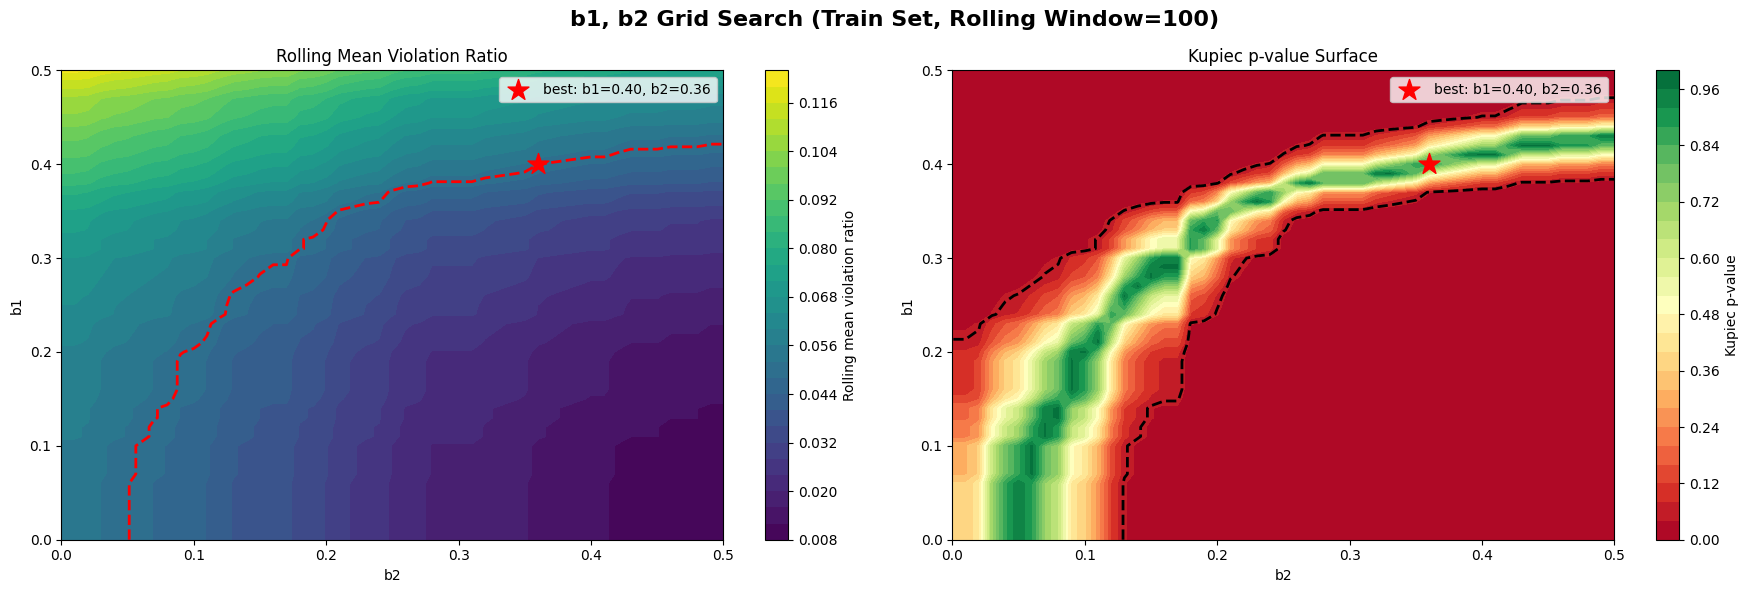

[경고] DDQN: 파일 없음 → ..\..\results\results_RL\DDQN_test_predictions_후보3.csv

[Test Backtest Results]


,Calibration,Model,b1,b2,Violations,Violation Rate,Kupiec p,Kupiec,Ind p,CC p,CC
0,Train,GJR-GARCH,-,-,52,0.0633,0.0932,Accept H0,0.3463,0.1569,Accept H0
1,Train,LR,0.4,0.36,76,0.0925,0.0000,Reject H0,0.6605,0.0000,Reject H0
2,Train,SVM,0.4,0.36,100,0.1217,0.0000,Reject H0,0.9530,0.0000,Reject H0
3,Train,ANN,0.4,0.36,84,0.1022,0.0000,Reject H0,0.8782,0.0000,Reject H0
4,Train,MLP,0.4,0.36,77,0.0937,0.0000,Reject H0,0.7526,0.0000,Reject H0



선택된 공통 calibration parameter
b1 = 0.400
b2 = 0.360


In [4]:
# =============================================
# b1, b2 choice - Train-only calibration
# 저장 기능 없음
# =============================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2
from pathlib import Path
from IPython.display import display

# =============================================
# 0. 설정
# =============================================
DATA_PATH = "../../data/processed/data_final.csv"

VAR_COL = "GJR_VaR_5_t1"
RET_T1_COL = "return_t1(%)"
LABEL_COL = "Risk_Label"

ALPHA = 0.05
WINDOW_SIZE = 100

b1_grid = np.linspace(0.0, 0.5, 51)
b2_grid = np.linspace(0.0, 0.5, 51)

# 모델별 test prediction 파일 설정
# 실제 파일명/컬럼명이 다르면 여기만 수정
model_configs = {
    "LR": {
        "test_path": "../../results/results_ML/01. LR_test_pred.csv",
        "pred_col": "LR_Pred"
    },
    "SVM": {
        "test_path": "../../results/results_ML/02. SVM_test_pred.csv",
        "pred_col": "SVM_Pred"
    },
    "ANN": {
        "test_path": "../../results/results_ML/03. ANN_test_pred.csv",
        "pred_col": "ANN_Pred"
    },
    "MLP": {
        "test_path": "../../results/results_ML/04. MLP_test_pred.csv",
        "pred_col": "MLP_Pred"
    },
    "DDQN": {
        "test_path": "../../results/results_RL/DDQN_test_predictions_후보3.csv",
        "pred_col": "DDQN_Prediction"
    },
}

# =============================================
# 1. Backtesting functions
# =============================================
def kupiec_test(T, n, alpha=0.05):
    if n <= 0:
        return np.nan, np.nan, "Invalid"

    pi_hat = T / n

    if T == 0 or T == n:
        return np.nan, np.nan, "Invalid"

    ll_null = (n - T) * np.log(1 - alpha) + T * np.log(alpha)
    ll_alt = (n - T) * np.log(1 - pi_hat) + T * np.log(pi_hat)

    lr_uc = -2 * (ll_null - ll_alt)
    p_value = 1 - chi2.cdf(lr_uc, df=1)

    decision = "Accept H0" if p_value >= 0.05 else "Reject H0"

    return lr_uc, p_value, decision


def christoffersen_test(violations):
    violations = np.asarray(violations).astype(int)

    if len(violations) < 2:
        return np.nan, np.nan, np.nan, np.nan, np.nan, np.nan, "Invalid"

    n00 = n01 = n10 = n11 = 0

    for i in range(1, len(violations)):
        prev_v = violations[i - 1]
        curr_v = violations[i]

        if prev_v == 0 and curr_v == 0:
            n00 += 1
        elif prev_v == 0 and curr_v == 1:
            n01 += 1
        elif prev_v == 1 and curr_v == 0:
            n10 += 1
        elif prev_v == 1 and curr_v == 1:
            n11 += 1

    n0 = n00 + n01
    n1 = n10 + n11

    pi01 = n01 / n0 if n0 > 0 else 0
    pi11 = n11 / n1 if n1 > 0 else 0
    pi = (n01 + n11) / (n0 + n1) if (n0 + n1) > 0 else 0

    eps = 1e-12

    ll_ind = (
        n00 * np.log(1 - pi01 + eps) +
        n01 * np.log(pi01 + eps) +
        n10 * np.log(1 - pi11 + eps) +
        n11 * np.log(pi11 + eps)
    )

    ll_null = (
        (n00 + n10) * np.log(1 - pi + eps) +
        (n01 + n11) * np.log(pi + eps)
    )

    lr_ind = -2 * (ll_null - ll_ind)
    p_ind = 1 - chi2.cdf(lr_ind, df=1)

    T = int(violations.sum())
    n = len(violations)

    lr_uc, p_uc, _ = kupiec_test(T, n, alpha=ALPHA)

    if np.isnan(lr_uc) or np.isnan(lr_ind):
        lr_cc = np.nan
        p_cc = np.nan
        decision_cc = "Invalid"
    else:
        lr_cc = lr_uc + lr_ind
        p_cc = 1 - chi2.cdf(lr_cc, df=2)
        decision_cc = "Accept H0" if p_cc >= 0.05 else "Reject H0"

    return lr_uc, p_uc, lr_ind, p_ind, lr_cc, p_cc, decision_cc


def clean_prediction_series(s):
    if pd.api.types.is_numeric_dtype(s):
        return s.astype(int)

    ss = (
        s.astype(str)
         .str.strip()
         .str.lower()
         .str.replace("_", " ", regex=False)
         .str.replace("-", " ", regex=False)
    )

    mapped = ss.map({
        "low risk": 0,
        "lowrisk": 0,
        "low": 0,
        "0": 0,
        "high risk": 1,
        "highrisk": 1,
        "high": 1,
        "1": 1
    })

    if mapped.isna().any():
        bad_values = s[mapped.isna()].value_counts(dropna=False)
        raise ValueError(f"예측값 변환 실패:\n{bad_values}")

    return mapped.astype(int)


# =============================================
# 2. 데이터 로드
# =============================================
df = pd.read_csv(DATA_PATH)

if "Date" in df.columns:
    df["Date"] = pd.to_datetime(df["Date"])
    df = df.sort_values("Date").reset_index(drop=True)
else:
    first_col = df.columns[0]

    if first_col.lower().startswith("unnamed") or first_col.lower() == "date":
        df = df.rename(columns={first_col: "Date"})
        df["Date"] = pd.to_datetime(df["Date"])
        df = df.sort_values("Date").reset_index(drop=True)
    else:
        raise ValueError("Date 컬럼을 찾을 수 없습니다.")

# Risk_Label 인코딩
label_raw = df[LABEL_COL].copy()

if pd.api.types.is_numeric_dtype(label_raw):
    df[LABEL_COL] = label_raw.astype(int)
else:
    label_clean = (
        label_raw
        .astype(str)
        .str.strip()
        .str.lower()
        .str.replace("_", " ", regex=False)
        .str.replace("-", " ", regex=False)
    )

    df[LABEL_COL] = label_clean.map({
        "low risk": 0,
        "lowrisk": 0,
        "low": 0,
        "0": 0,
        "high risk": 1,
        "highrisk": 1,
        "high": 1,
        "1": 1
    })

    if df[LABEL_COL].isna().any():
        print("Risk_Label 변환 실패 값:")
        print(label_raw[df[LABEL_COL].isna()].value_counts(dropna=False))
        raise ValueError("Risk_Label 인코딩 실패")

    df[LABEL_COL] = df[LABEL_COL].astype(int)

print("Risk_Label 인코딩 완료")
print(df[LABEL_COL].value_counts())
print()

required_cols = ["Date", VAR_COL, RET_T1_COL, LABEL_COL]
missing_cols = [c for c in required_cols if c not in df.columns]

if missing_cols:
    raise ValueError(f"필요한 컬럼이 없습니다: {missing_cols}")

if df[[VAR_COL, RET_T1_COL, LABEL_COL]].isna().any().any():
    print(df[[VAR_COL, RET_T1_COL, LABEL_COL]].isna().sum())
    raise ValueError("VaR, return_t1, Risk_Label 중 결측치가 있습니다.")

# =============================================
# 3. train / valid / test split = 45 / 35 / 20
# =============================================
n_total = len(df)

train_end = int(n_total * 0.45)
valid_end = int(n_total * 0.80)

df_train = df.iloc[:train_end].copy()
df_valid = df.iloc[train_end:valid_end].copy()
df_test = df.iloc[valid_end:].copy()

df_calib = df_train.copy()

CALIB_NAME = "Train"

print("=" * 60)
print("Split check")
print("=" * 60)
print(f"Full        : {len(df)} | {df['Date'].min().date()} ~ {df['Date'].max().date()}")
print(f"Train       : {len(df_train)} | {df_train['Date'].min().date()} ~ {df_train['Date'].max().date()}")
print(f"Valid       : {len(df_valid)} | {df_valid['Date'].min().date()} ~ {df_valid['Date'].max().date()}")
print(f"Calibration : {len(df_calib)} | {df_calib['Date'].min().date()} ~ {df_calib['Date'].max().date()}  <- b1,b2 calibration")
print(f"Test        : {len(df_test)} | {df_test['Date'].min().date()} ~ {df_test['Date'].max().date()}  <- final backtest")
print("=" * 60)
print()

# =============================================
# 4. Calibration arrays
# =============================================
var_calib = df_calib[VAR_COL].to_numpy(dtype=float)
ret_calib = df_calib[RET_T1_COL].to_numpy(dtype=float)
action_calib = df_calib[LABEL_COL].to_numpy(dtype=int)

n_calib_len = len(df_calib)

var_test = df_test[VAR_COL].to_numpy(dtype=float)
ret_test = df_test[RET_T1_COL].to_numpy(dtype=float)
n_test = len(df_test)

print("비교 기준 확인")
print(f"Violation 기준: {RET_T1_COL} < {VAR_COL}")
print(f"{CALIB_NAME} 기준 기대 위반 횟수: {n_calib_len * ALPHA:.1f}회")
print(f"Test 기준 기대 위반 횟수       : {n_test * ALPHA:.1f}회")
print()

base_violation_calib = ret_calib < var_calib

print(f"[{CALIB_NAME} baseline violation]")
print("전체 baseline violation rate:", round(base_violation_calib.mean(), 4))
print("전체 baseline violation count:", int(base_violation_calib.sum()))

print(f"\n[{CALIB_NAME} Risk_Label별 baseline violation]")
for label_value, label_name in [(0, "Low Risk"), (1, "High Risk")]:
    mask = action_calib == label_value

    print(f"\n{label_name}")
    print("n:", int(mask.sum()))
    print("violation count:", int(base_violation_calib[mask].sum()))
    print("violation rate:", round(base_violation_calib[mask].mean(), 4) if mask.sum() > 0 else np.nan)

print()

# =============================================
# 5. b1, b2 grid search
# =============================================
coverage = np.zeros((len(b1_grid), len(b2_grid)))
pvalue_matrix = np.zeros((len(b1_grid), len(b2_grid)))
loss_matrix = np.zeros((len(b1_grid), len(b2_grid)))

print(f"b1, b2 grid search 중... ({CALIB_NAME} 기준)")

for i, b1 in enumerate(b1_grid):
    for j, b2 in enumerate(b2_grid):

        var_adj_calib = np.where(
            action_calib == 0,
            var_calib * (1.0 - b1),
            var_calib * (1.0 + b2)
        )

        rolling_ratios = []

        if n_calib_len >= WINDOW_SIZE:
            for start in range(n_calib_len - WINDOW_SIZE + 1):
                end = start + WINDOW_SIZE
                ratio = (ret_calib[start:end] < var_adj_calib[start:end]).mean()
                rolling_ratios.append(ratio)

            mean_ratio = float(np.mean(rolling_ratios))
        else:
            mean_ratio = float((ret_calib < var_adj_calib).mean())

        coverage[i, j] = mean_ratio
        loss_matrix[i, j] = abs(mean_ratio - ALPHA)

        T_calib = int((ret_calib < var_adj_calib).sum())
        _, pval, _ = kupiec_test(T_calib, n_calib_len, alpha=ALPHA)
        pvalue_matrix[i, j] = pval if not np.isnan(pval) else 0.0

# 최적 선택: valid 때와 동일하게 loss_matrix argmin 기준
best_idx = np.unravel_index(np.nanargmin(loss_matrix), loss_matrix.shape)

b1_best = float(b1_grid[best_idx[0]])
b2_best = float(b2_grid[best_idx[1]])
best_ratio = float(coverage[best_idx])
best_pvalue = float(pvalue_matrix[best_idx])

min_loss = np.nanmin(loss_matrix)
candidate_rows = []

for i, b1 in enumerate(b1_grid):
    for j, b2 in enumerate(b2_grid):
        loss_val = loss_matrix[i, j]

        if loss_val <= min_loss + 1e-12:
            candidate_rows.append({
                "i": i,
                "j": j,
                "b1": float(b1),
                "b2": float(b2),
                "loss": float(loss_val),
                "coverage": float(coverage[i, j]),
                "pvalue": float(pvalue_matrix[i, j])
            })

candidate_df = pd.DataFrame(candidate_rows).sort_values(
    by=["i", "j"],
    ascending=[True, True]
).reset_index(drop=True)

print("\n" + "=" * 60)
print(f"Grid Search 결과 - {CALIB_NAME} Calibration")
print("=" * 60)
print(f"최적 b1              = {b1_best:.3f}")
print(f"최적 b2              = {b2_best:.3f}")
print(f"{CALIB_NAME} 위반율   = {best_ratio:.4f}")
print(f"{CALIB_NAME} p-value  = {best_pvalue:.4f}")
print(f"기대 위반율          = {ALPHA:.4f}")
print(f"동일 최적 후보 수    = {len(candidate_df)}")
print("=" * 60)

display(candidate_df.head(20))

# =============================================
# 6. Contour plot
# =============================================
B2, B1 = np.meshgrid(b2_grid, b1_grid)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

cont1 = axes[0].contourf(
    B2,
    B1,
    coverage,
    levels=30,
    cmap="viridis"
)

fig.colorbar(cont1, ax=axes[0], label="Rolling mean violation ratio")

try:
    axes[0].contour(
        B2,
        B1,
        coverage,
        levels=[ALPHA],
        colors="red",
        linestyles="--",
        linewidths=2
    )
except Exception:
    pass

axes[0].scatter(
    b2_best,
    b1_best,
    color="red",
    marker="*",
    s=250,
    label=f"best: b1={b1_best:.2f}, b2={b2_best:.2f}"
)

axes[0].set_title("Rolling Mean Violation Ratio")
axes[0].set_xlabel("b2")
axes[0].set_ylabel("b1")
axes[0].legend()

cont2 = axes[1].contourf(
    B2,
    B1,
    pvalue_matrix,
    levels=30,
    cmap="RdYlGn"
)

fig.colorbar(cont2, ax=axes[1], label="Kupiec p-value")

try:
    axes[1].contour(
        B2,
        B1,
        pvalue_matrix,
        levels=[0.05],
        colors="black",
        linestyles="--",
        linewidths=2
    )
except Exception:
    pass

axes[1].scatter(
    b2_best,
    b1_best,
    color="red",
    marker="*",
    s=250,
    label=f"best: b1={b1_best:.2f}, b2={b2_best:.2f}"
)

axes[1].set_title("Kupiec p-value Surface")
axes[1].set_xlabel("b2")
axes[1].set_ylabel("b1")
axes[1].legend()

fig.suptitle(
    f"b1, b2 Grid Search ({CALIB_NAME} Set, Rolling Window={WINDOW_SIZE})",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

# =============================================
# 7. Test baseline and adjusted VaR
# =============================================
results = []

T_orig = int((ret_test < var_test).sum())
violation_rate_orig = T_orig / n_test

lr_uc_o, pv_uc_o, dec_uc_o = kupiec_test(T_orig, n_test, alpha=ALPHA)

I_orig = (ret_test < var_test).astype(int)
_, _, lr_ind_o, pv_ind_o, lr_cc_o, pv_cc_o, dec_cc_o = christoffersen_test(I_orig)

results.append({
    "Calibration": CALIB_NAME,
    "Model": "GJR-GARCH",
    "b1": "-",
    "b2": "-",
    "Violations": T_orig,
    "Violation Rate": round(violation_rate_orig, 4),
    "Kupiec p": round(pv_uc_o, 4) if not np.isnan(pv_uc_o) else "-",
    "Kupiec": dec_uc_o,
    "Ind p": round(pv_ind_o, 4) if not np.isnan(pv_ind_o) else "-",
    "CC p": round(pv_cc_o, 4) if not np.isnan(pv_cc_o) else "-",
    "CC": dec_cc_o
})

for model_name, config in model_configs.items():

    test_path = Path(config["test_path"])
    pred_col = config["pred_col"]

    if not test_path.exists():
        print(f"[경고] {model_name}: 파일 없음 → {test_path}")
        continue

    df_pred = pd.read_csv(test_path)

    if pred_col not in df_pred.columns:
        print(f"[경고] {model_name}: 예측 컬럼 없음 → {pred_col}")
        print("사용 가능 컬럼:", df_pred.columns.tolist())
        continue

    if "Date" in df_pred.columns:
        df_pred["Date"] = pd.to_datetime(df_pred["Date"])
        df_pred = df_pred.sort_values("Date").reset_index(drop=True)

        test_dates = df_test["Date"].reset_index(drop=True)

        if not df_pred["Date"].reset_index(drop=True).equals(test_dates):
            print(f"[경고] {model_name}: test Date 불일치. 진행하지 않음.")
            print("pred 기간:", df_pred["Date"].min(), "~", df_pred["Date"].max())
            print("true 기간:", test_dates.min(), "~", test_dates.max())
            continue

    if len(df_pred) != n_test:
        print(f"[경고] {model_name}: test 길이 불일치 ({len(df_pred)} vs {n_test})")
        continue

    action_test_pred = clean_prediction_series(df_pred[pred_col]).to_numpy(dtype=int)

    var_adj_test = np.where(
        action_test_pred == 0,
        var_test * (1.0 - b1_best),
        var_test * (1.0 + b2_best)
    )

    violation_test = ret_test < var_adj_test

    T_ml = int(violation_test.sum())
    violation_rate_ml = T_ml / n_test

    lr_uc_m, pv_uc_m, dec_uc_m = kupiec_test(T_ml, n_test, alpha=ALPHA)

    I_ml = violation_test.astype(int)
    _, _, lr_ind_m, pv_ind_m, lr_cc_m, pv_cc_m, dec_cc_m = christoffersen_test(I_ml)

    results.append({
        "Calibration": CALIB_NAME,
        "Model": model_name,
        "b1": round(b1_best, 3),
        "b2": round(b2_best, 3),
        "Violations": T_ml,
        "Violation Rate": round(violation_rate_ml, 4),
        "Kupiec p": round(pv_uc_m, 4) if not np.isnan(pv_uc_m) else "-",
        "Kupiec": dec_uc_m,
        "Ind p": round(pv_ind_m, 4) if not np.isnan(pv_ind_m) else "-",
        "CC p": round(pv_cc_m, 4) if not np.isnan(pv_cc_m) else "-",
        "CC": dec_cc_m
    })

result_df = pd.DataFrame(results)

print("\n[Test Backtest Results]")
display(result_df)

print("\n선택된 공통 calibration parameter")
print(f"b1 = {b1_best:.3f}")
print(f"b2 = {b2_best:.3f}")

In [5]:
#혹시나 한국주식 데이터의 특성을 설명 할 수 있을까봐 추가 기술로 보류
import scipy.stats as stats

ret = df["return(%)"]

print(f"Mean:     {ret.mean():.4f}")
print(f"Std:      {ret.std():.4f}")
print(f"Skewness: {ret.skew():.4f}")
print(f"Kurtosis: {ret.kurtosis():.4f}")  # excess kurtosis
jb_stat, jb_p = stats.jarque_bera(ret)
print(f"JB stat:  {jb_stat:.4f}")
print(f"JB p:     {jb_p:.4f}")
print(f"Min:      {ret.min():.4f}")
print(f"Max:      {ret.max():.4f}")

Mean:     0.0415
Std:      1.1728
Skewness: -0.2396
Kurtosis: 5.3636
JB stat:  4948.8008
JB p:     0.0000
Min:      -9.5650
Max:      8.7548
